## **Analiza sygnału EKG**
### Autorzy: Jakub Grobelny (252849), Zuzanna Rykaczewska (251275)

#### 1. Wczytywanie danych i wstępna analiza sygnału

In [61]:
import pandas as pd

with open('normal_small.xlsx', 'rb') as file:
    data = pd.read_excel(file, skiprows=1).astype(float).values

df = pd.DataFrame(data)
df.columns = ['Time', 'Voltage [mV]']
df.index = df.index + 1
df.head()

,Time,Voltage [mV]
1,0.007989,-0.435
2,0.011984,-0.392
3,0.015979,-0.394
4,0.019973,-0.376
5,0.023968,-0.414


In [62]:
# Wyliczenie fs
delta_t = df["Time"].diff().mean()
fs = 1 / delta_t
print(f"Częstotliwość próbkowania wynosi: {round(fs, 0)} [Hz]")

Częstotliwość próbkowania wynosi: 250.0 [Hz]


### Analiza częstotliwości składowych (FFT)

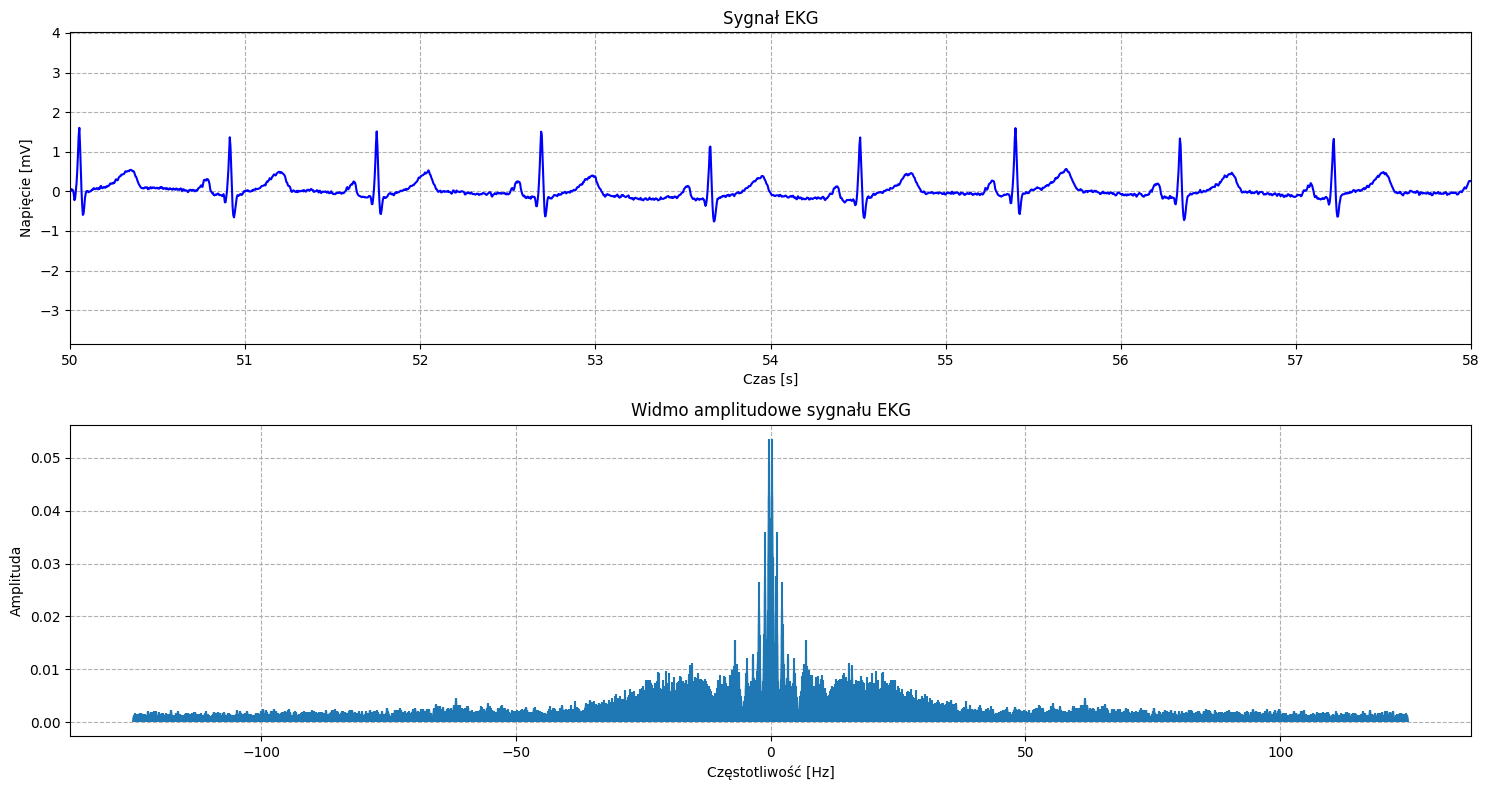

In [63]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import numpy as np

def fft_signal_plot(signal, t, fs, title, fft_title):
    # Wyliczanie fft
    n = len(signal)
    delta_t = 1.0 / fs
    fft_values = np.fft.fft(signal)
    freq = np.fft.fftfreq(n, d=delta_t)
    amplitude = np.abs(fft_values) * (2.0 / n)
    
    # Wykres sygnału i jego widma
    fig, ax = plt.subplots(2, 1, figsize=(15, 8))

    ax[0].plot(t, signal, color='blue')
    ax[0].set_title(title)
    ax[0].set_xlabel('Czas [s]')
    ax[0].set_xlim(50, 58)
    ax[0].set_ylabel('Napięcie [mV]')
    ax[0].grid(linestyle='--')

    ax[1].stem(freq, amplitude, linefmt='-', markerfmt=' ', basefmt=' ')
    ax[1].set_title(fft_title)
    ax[1].set_xlabel('Częstotliwość [Hz]')
    ax[1].set_ylabel('Amplituda')
    ax[1].grid(linestyle='--')

    plt.tight_layout()

# Wykres dla surowego sygnału EKG i jego widma
fft_signal_plot(df["Voltage [mV]"].values, df["Time"].values, fs=250, title="Sygnał EKG", fft_title="Widmo amplitudowe sygnału EKG")

## Preprocesing

##### 1. Usunięcie dryftu (Baseline)

C:\Users\HP\AppData\Local\Temp\ipykernel_7884\2486677715.py:8: RuntimeWarning: divide by zero encountered in log10
  ax.plot(w, 20*np.log10(np.abs(h)))


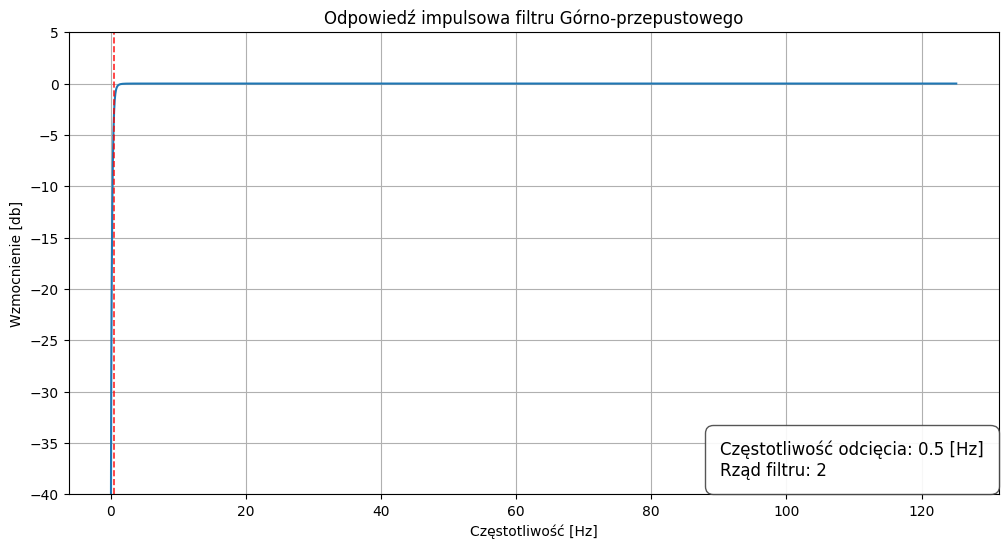

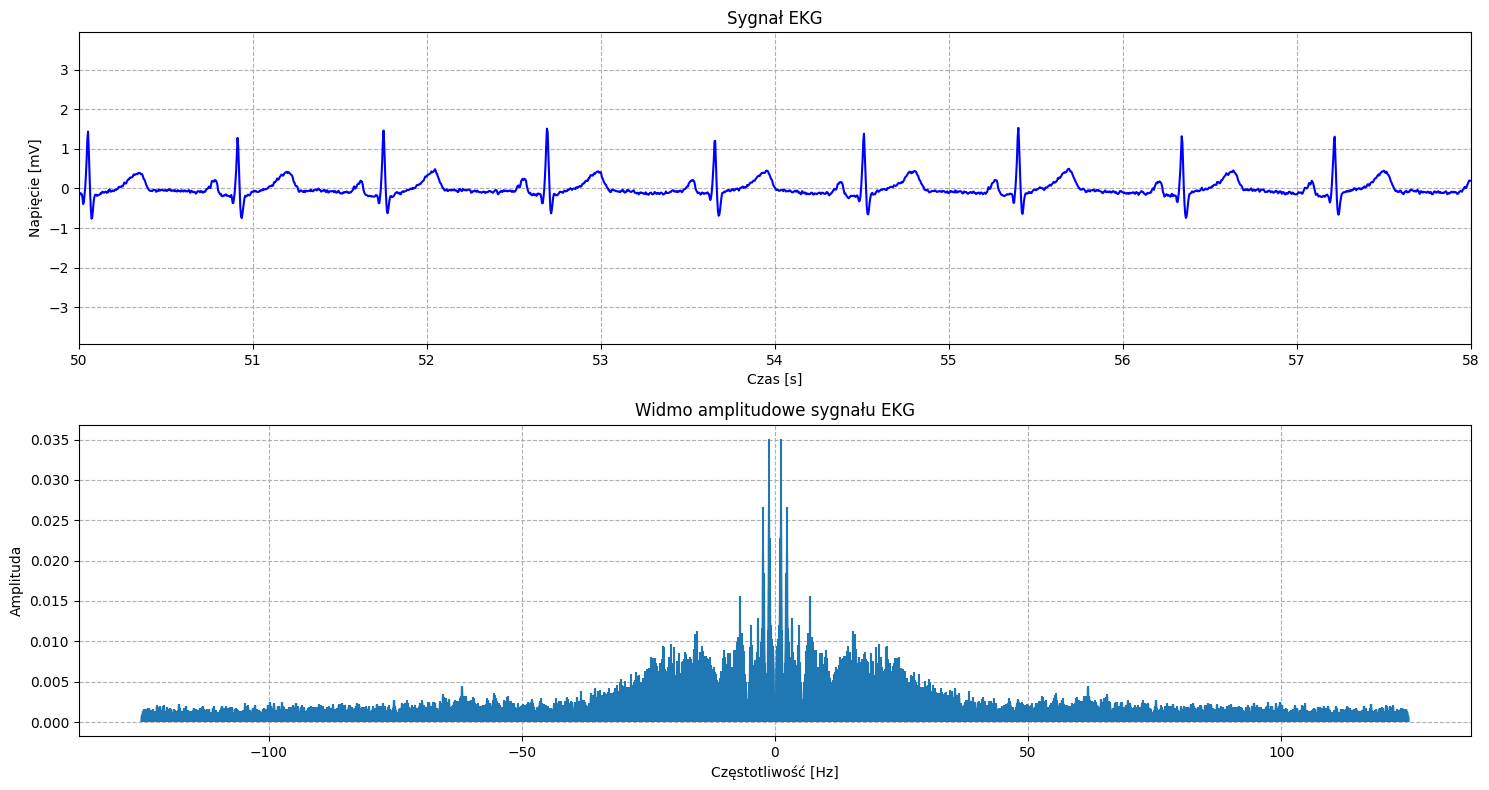

In [64]:
from scipy import signal

def odpowiedz_impulsowa(w, h, title, fs_cut, txt):
    txt = str(txt)

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111)
    ax.plot(w, 20*np.log10(np.abs(h)))
    ax.set_ylim(-40, 5)
    ax.grid(True)
    ax.set_xlabel('Częstotliwość [Hz]')
    ax.set_ylabel('Wzmocnienie [db]')
    ax.set_title(title)
    ax.axvline(fs_cut, color='red', ls='--', lw=1.2, alpha=0.85)

    # Opis filtru
    at = AnchoredText(txt, loc='lower right', prop=dict(size=12), frameon=True)
    at.patch.set_boxstyle("round,pad=0.5")
    at.patch.set_facecolor("white")
    at.patch.set_alpha(0.9)
    at.patch.set_edgecolor("#444")
    ax.add_artist(at)
    plt.show()


hpf_cutoff = 0.5    
hpf_order = 2 

b_hp, a_hp = signal.butter(hpf_order, hpf_cutoff, btype='high', fs=fs)
w_hp, h_hp = signal.freqz(b_hp, a_hp, worN=4096, fs=fs)

odpowiedz_impulsowa(w_hp, h_hp, 'Odpowiedź impulsowa filtru Górno-przepustowego', hpf_cutoff,
                        f"Częstotliwość odcięcia: {hpf_cutoff} [Hz]\nRząd filtru: {hpf_order}")
hp_filtred_signal = signal.filtfilt(b_hp, a_hp, df["Voltage [mV]"].values) # Odfiltrowany sygnał

# Wyniki po filtracji
fft_signal_plot(hp_filtred_signal, df["Time"].values, fs=250, title="Sygnał EKG", fft_title="Widmo amplitudowe sygnału EKG")

#### 2. Usinięcie szumu szumu wynikającego z interferencji lini energetycznych

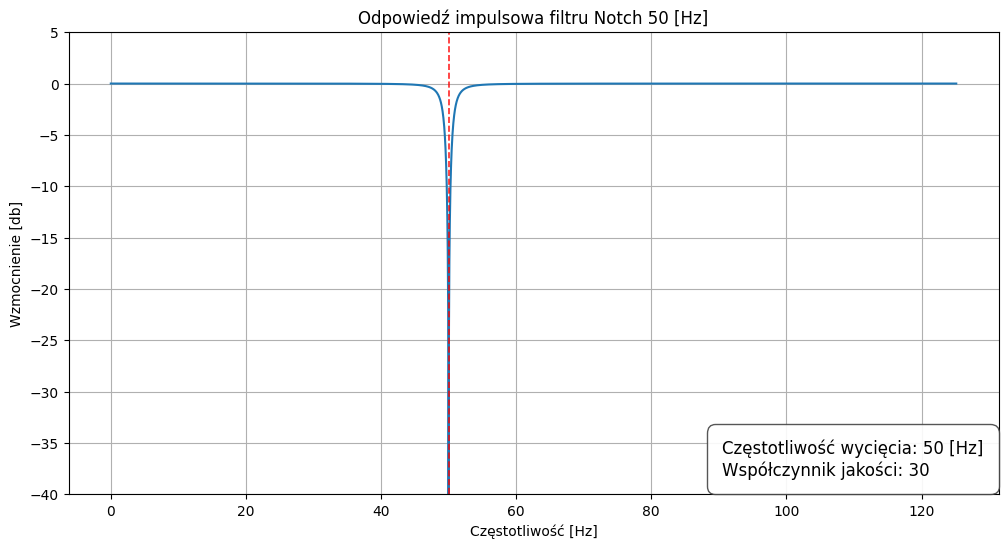

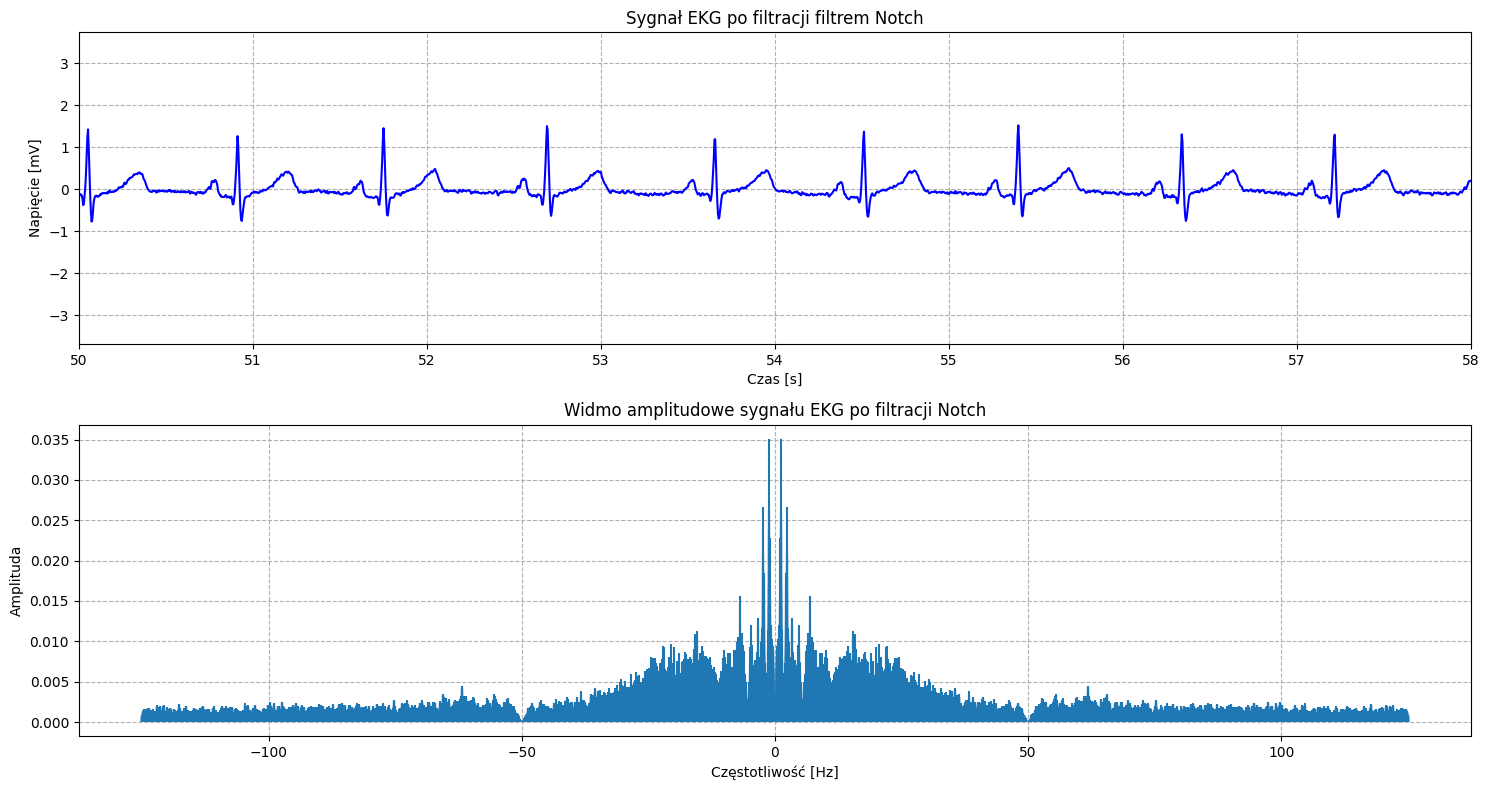

In [65]:
center_freq = 50
Q = 30

b_notch, a_notch = signal.iirnotch(center_freq, Q, fs)
w_notch, h_notch = signal.freqz(b_notch, a_notch, worN=4096, fs=fs)

odpowiedz_impulsowa(w_notch, h_notch, 'Odpowiedź impulsowa filtru Notch 50 [Hz]', center_freq,
                        f"Częstotliwość wycięcia: {center_freq} [Hz]\nWspółczynnik jakości: {Q}")

notch_filtred_signal = signal.filtfilt(b_notch, a_notch, hp_filtred_signal)
fft_signal_plot(notch_filtred_signal, df["Time"].values, fs=250, title="Sygnał EKG po filtracji filtrem Notch", fft_title="Widmo amplitudowe sygnału EKG po filtracji Notch")

#### 3. Redukcja szumów wysokoczęstotliwościowych

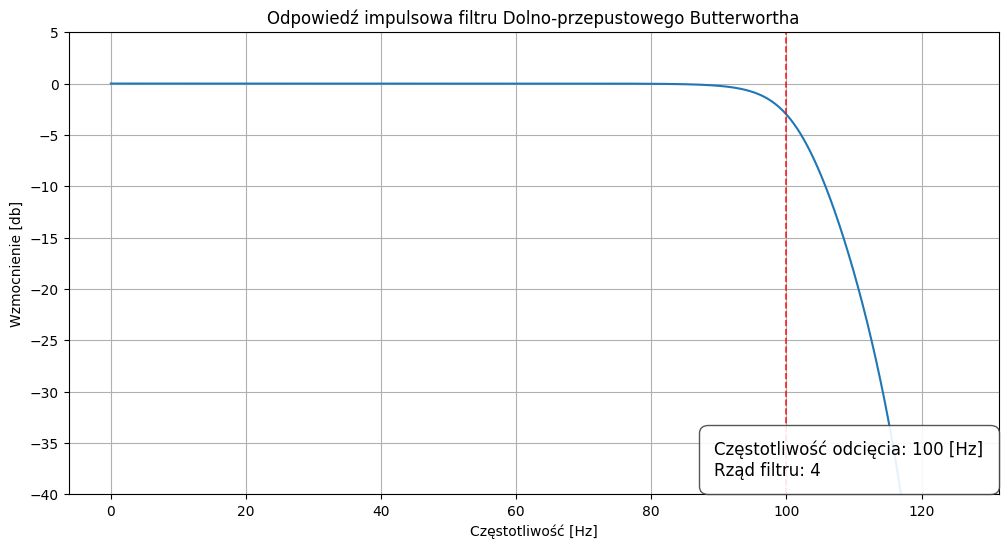

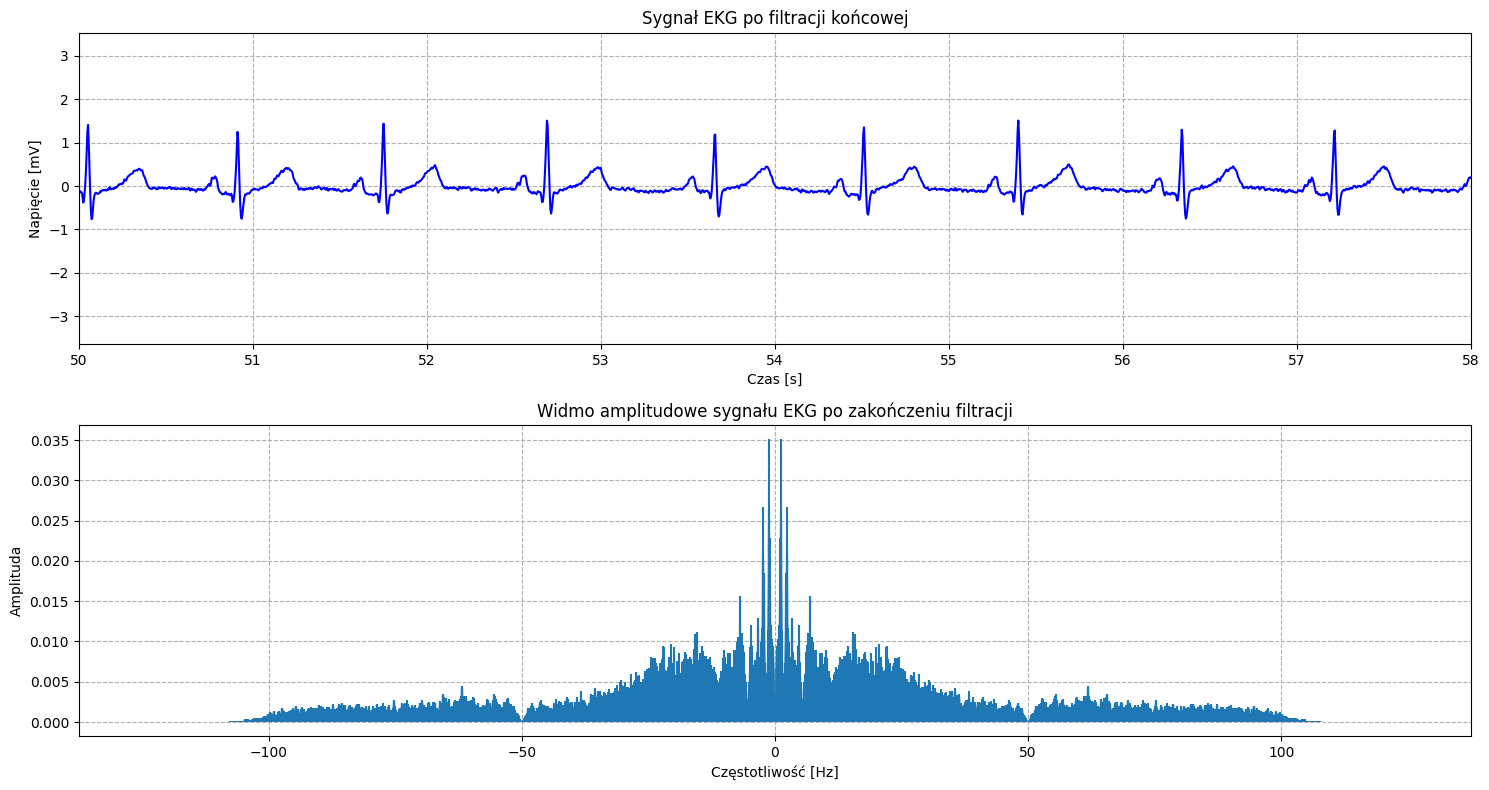

In [66]:
lpf_cutoff = 100
lpf_order = 4

b_lpf, a_lpf = signal.butter(lpf_order, lpf_cutoff/(fs/2), btype='low', analog=False)
w_lpf, h_lpf = signal.freqz(b_lpf, a_lpf, worN=4096, fs=fs)

odpowiedz_impulsowa(w_lpf, h_lpf, 'Odpowiedź impulsowa filtru Dolno-przepustowego Butterwortha', lpf_cutoff,
                        f"Częstotliwość odcięcia: {lpf_cutoff} [Hz]\nRząd filtru: {lpf_order}")

filtred_signal = signal.filtfilt(b_lpf, a_lpf, notch_filtred_signal) # Filtracja końcowa
fft_signal_plot(filtred_signal, df["Time"].values, fs=250, title="Sygnał EKG po filtracji końcowej", fft_title="Widmo amplitudowe sygnału EKG po zakończeniu filtracji")

## Analiza sygnału

#### Wykrywanie załamków QRS

In [67]:
r_peaks = signal.find_peaks(filtred_signal, distance=int(fs*0.5))[0]
r_peaks = r_peaks[6:] # Usuwamy pierwsze piki analizy

def window(signal, center, fs, before_ms, after_ms):
    before = int(before_ms * fs / 1000)
    after  = int(after_ms  * fs / 1000)
    lo = max(center - before, 0)
    hi = min(center + after, len(signal)-1)
    idx = np.arange(lo, hi)
    return idx, signal[lo:hi]

def find_Q(signal, r_idx, fs, lookback_ms=40):
    """Q to minimum amplitudy w oknie chwile przed R"""
    idx, seg = window(signal, r_idx, fs, lookback_ms, 0)
    if len(seg) < 3:
        return max(r_idx - int(0.02 * fs), 0)
    
    q = np.argmin(seg)
    return int(idx[q])

def find_S(signal, r_idx, fs, lookahead_ms=0):
    """S to minimum amplitudy w oknie chwile po R"""
    idx, seg = window(signal, r_idx, fs, 0, lookahead_ms)
    if len(seg) < 3:
        return min(r_idx + int(0.02 * fs), len(signal)-1)
    
    s = np.argmin(seg)
    return int(idx[s])

q_peaks = [find_Q(filtred_signal, r, fs) for r in r_peaks]
s_peaks = [find_S(filtred_signal, r, fs) for r in r_peaks]

q_peaks = np.array(q_peaks, dtype=int)
s_peaks = np.array(s_peaks, dtype=int)

qrs_mv = {
    "Załamek Q" : filtred_signal[q_peaks],
    "Załamek R" : filtred_signal[r_peaks],
    "Załamek S" : filtred_signal[s_peaks]
}

### Elementy zespołu QRS w sygnale EKG

In [68]:
qrs = pd.DataFrame(qrs_mv)
qrs.index =qrs.index + 1
qrs.columns = ["Załamek Q [mV]", "Załamek R [mV]", "Załamek S [mV]"]

qrs.head(15)

,Załamek Q [mV],Załamek R [mV],Załamek S [mV]
1,-0.287395,1.292239,-0.624281
2,-0.293635,1.432788,-0.467348
3,-0.258500,1.399263,-0.626001
4,-0.390337,1.265258,-0.702412
5,-0.370879,1.459044,-0.573302
6,-0.283351,1.397401,-0.646647
7,-0.372906,1.311621,-0.667866
8,-0.341882,1.589746,-0.466611
9,-0.364835,1.506573,-0.603378
10,-0.347601,1.283820,-0.726629


#### Wykrywanie fal P i T

In [69]:
def find_P(signal_data, r_idx, fs):
    """ Fala P to maksimum amplitudy w oknie od 200ms do 50ms przed R """
    idx, seg = window(signal_data, r_idx, fs, 200, -50)
    if len(seg) < 5: return None
    
    peaks, _ = signal.find_peaks(seg, distance=int(fs*0.04)) 
    if len(peaks) == 0:
        p_peak_rel = np.argmax(seg)
    else:
        best_peak_idx = np.argmax(seg[peaks])
        p_peak_rel = peaks[best_peak_idx]

    p_peak_idx = idx[p_peak_rel]
    p_peak_val = seg[p_peak_rel]

    local_min = np.min(seg)
    amplitude_diff = p_peak_val - local_min
    threshold = p_peak_val - (amplitude_diff * 0.90)
    p_start_idx = idx[0] 
    
    for i in range(p_peak_rel, -1, -1):
        if seg[i] <= threshold:
            p_start_idx = idx[i]
            break

    p_end_idx = idx[-1]
    for i in range(p_peak_rel, len(seg)):
        if seg[i] <= threshold:
            p_end_idx = idx[i]
            break
            
    return {"start": p_start_idx, "peak": p_peak_idx, "end": p_end_idx}


def find_T(signal_data, r_idx, fs):
    """ Fala T to maksimum amplitudy w oknie od 100ms do 450ms po R """
    idx, seg = window(signal_data, r_idx, fs, -100, 450)
    if len(seg) < 5: return None
    peaks, _ = signal.find_peaks(seg, distance=int(fs*0.1))
    
    if len(peaks) == 0:
         t_peak_rel = np.argmax(seg)
    else:
         best_peak_idx = np.argmax(seg[peaks])
         t_peak_rel = peaks[best_peak_idx]
         
    t_peak_idx = idx[t_peak_rel]
    t_peak_val = seg[t_peak_rel]
    
    local_min = np.min(seg)
    amplitude_diff = t_peak_val - local_min
    threshold = t_peak_val - (amplitude_diff * 0.85)
    
    t_start_idx = t_peak_idx
    for i in range(t_peak_rel, 0, -1):
        if seg[i] <= threshold:
            t_start_idx = idx[i]
            break
            
    t_end_idx = t_peak_idx
    for i in range(t_peak_rel, len(seg)):
        if seg[i] <= threshold:
            t_end_idx = idx[i]
            break
            
    return {"start": t_start_idx, "peak": t_peak_idx, "end": t_end_idx}

all_cicles = []

for r in r_peaks:
    p_wave = find_P(filtred_signal, r, fs)
    t_wave = find_T(filtred_signal, r, fs)
    q_idx = find_Q(filtred_signal, r, fs)
    s_idx = find_S(filtred_signal, r, fs)

    if p_wave is not None and t_wave is not None:
        cycle = {"P_start" : p_wave["start"], "P_peak" : p_wave["peak"], "P_end" : p_wave["end"],
                "Q" : q_idx,
                "R" : r,
                "S" : s_idx,
                "T_start" : t_wave["start"], "T_peak" : t_wave["peak"], "T_end" : t_wave["end"]
                }
        all_cicles.append(cycle)
    else:
        print(f"Pominięto cykl przy R={r}, ponieważ sygnał jest tam ucięty (brak P lub T)")

df_peaks = pd.DataFrame(all_cicles)

Pominięto cykl przy R=65517, ponieważ sygnał jest tam ucięty (brak P lub T)


#### Wizualizacja wyników

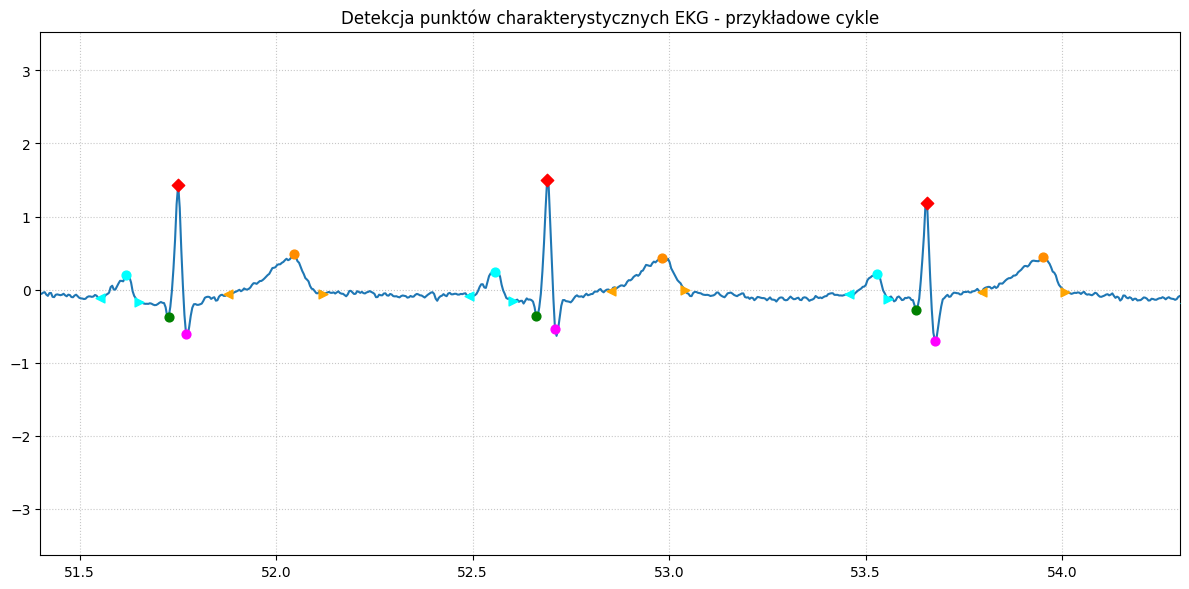

In [70]:
def plot_points(col_name, color, label, marker='o'):
    indices = df_peaks[col_name].values
    plt.scatter(df["Time"].values[indices], filtred_signal[indices], c=color, label=label, marker=marker, s=40, zorder=5)

plt.figure(figsize=(12, 6))
plt.plot(df["Time"], filtred_signal, label='Sygnał EKG')
plot_points("P_start", "cyan", "P wave start", marker='<')
plot_points("P_peak", "cyan", "P peak")
plot_points("P_end", "cyan", "P wave end", marker='>')

plot_points("Q", "green", "Q")
plot_points("R", "red", "R", marker='D')
plot_points("S", "magenta", "S")

plot_points("T_start", "orange", "T wave start", marker='<')
plot_points("T_peak", "darkorange", "T wave peak")
plot_points("T_end", "orange", "T wave end", marker='>')

plt.xlim(51.4, 54.3) 
plt.title("Detekcja punktów charakterystycznych EKG - przykładowe cykle")
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#### Wyliczanie interwałów czasowych dla sygnału

In [71]:
df_peaks.index = df_peaks.index + 1
df_peaks.head(15)

,P_start,P_peak,P_end,Q,R,S,T_start,T_peak,T_end
1,1290,1308,1314,1333,1340,1345,1412,1412,1427
2,1513,1531,1541,1557,1563,1568,1590,1636,1648
3,1754,1772,1783,1797,1804,1809,1876,1876,1891
4,1969,1987,1993,2012,2019,2024,2065,2087,2107
5,2190,2208,2218,2233,2240,2245,2277,2312,2328
6,2426,2441,2452,2467,2473,2478,2546,2546,2560
7,2661,2679,2693,2705,2711,2716,2751,2785,2785
8,2894,2913,2923,2938,2944,2949,2978,3016,3032
9,3135,3153,3161,3179,3185,3190,3224,3255,3274
10,3380,3398,3414,3424,3430,3435,3456,3503,3517


In [72]:

rr_intervals = np.diff(df_peaks['R']) / fs
bpm = 60 / rr_intervals
qr_intervals = (df_peaks['R'] - df_peaks['Q']) / fs
qrs_duration = (df_peaks['S'] - df_peaks['Q']) / fs
rs_intervals = (df_peaks['S'] - df_peaks['R']) / fs
qt_intervals = (df_peaks['T_end'] - df_peaks['Q']) / fs

stats = pd.DataFrame({
    "Parametr": ["Puls (BPM)", "RR [s]", "QR [s]", "QRS [s]", "RS [s]", "QT [s]"],
    "Średnia": [
        np.mean(bpm),
        np.mean(rr_intervals),
        np.mean(qr_intervals),
        np.mean(qrs_duration),
        np.mean(rs_intervals),
        np.mean(qt_intervals)
    ],
    "Std": [
        np.std(bpm),
        np.std(rr_intervals),
        np.std(qr_intervals),
        np.std(qrs_duration),
        np.std(rs_intervals),
        np.std(qt_intervals)
    ]
})
stats.head(6)

,Parametr,Średnia,Std
0,Puls (BPM),73.666845,12.698121
1,RR [s],0.832076,0.104183
2,QR [s],0.025888,0.003774
3,QRS [s],0.045861,0.003774
4,RS [s],0.019973,0.000000
5,QT [s],0.374955,0.032585
